In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.DataFrame( {
    "std" : [ 'a' , 'b' , 'c' , 'd' , 'e' ],
    'M' : [ 78,90,67,88,90 ],
    "S" : [85,92,70,88,85]
} )
df

,std,M,S
0,a,78,85
1,b,90,92
2,c,67,70
3,d,88,88
4,e,90,85


In [3]:
result = df.sort_values( by=["M" , "S"] , ascending=[False,True] )
result

,std,M,S
4,e,90,85
1,b,90,92
3,d,88,88
0,a,78,85
2,c,67,70


In [4]:
df1 = pd.DataFrame( {
    "City" : ['a','b','c','b','a']
} )

df2 = df1.replace( { 'a' : 'x' , 'b' : 'y' } )
df2['City'].unique()

array(['x', 'y', 'c'], dtype=object)

In [5]:
df1.index[0]

0

In [6]:
len(df1)

5

In [7]:
import pandas as pd
df = pd.DataFrame({
 "Team":["X","Y","X","Y","X"],
 "Runs":[50,60,70,80,90]
})
result = df.groupby("Team")["Runs"].mean()
result["X"]

np.float64(70.0)

In [8]:
import pandas as pd
df = pd.DataFrame({
 "Team":["X","X","Y","Y"],
 "Score":[10,20,30,40]
})
result = df.groupby("Team").nth(1)
# print(result.loc["X"])
result

,Team,Score
1,X,20
3,Y,40


In [9]:
df = pd.DataFrame( [
    [1,2,3,4,5],
    [2,3,4,5,6],
    [None,None,None,None,None]
] )
df.dropna(axis=1,thresh=3,inplace=True)
df.shape[1]

0

Using ‘supermarket_sales.csv’ file do the following operations and give required answer by using proper programming process.
1). Load the dataset into a pandas DataFrame and read first 8 rows.
2). Check for missing values and fill it by mean values of that particular column if any.
3). Find the number of orders which have ‘Quantity’ less than 3 and which have (either ‘Rating’ greater than 8.5 or ‘Total’
greater than 600).
4). Find the sum of ‘Total’ purchasing price spent by Member and Normal 'Customer type'.
5). Find the percentage of total of ‘gross income’ based on the different ‘Payment’ methods used by customers. (Ewallet, Cash
and Credit card)
6). Analyze the purchasing behavior of male and female customers using ‘Gender’ column. Find their average purchase prices
using ‘Total’ column.
7). Create a scatter plot that shows the relationship between total amount spent and rating.
8). Create a box plot that shows the distribution of ‘Rating’ and ‘Quantity’. And comment about outliers in both columns.
9). Visualize with parallel co-ordinates for ‘Unit price’, ‘Total’, ’cogs’ columns’ data with respect to ‘Product line’.

In [ ]:
df = pd.read_csv("supermarket_sales.csv")
df

In [12]:
df.head(8)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01-05-2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03-08-2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03-03-2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02-08-2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,18:30,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2/25/2019,14:36,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38,Ewallet,735.60,4.761905,36.7800,8.0


In [15]:
df.isna().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       4
gross margin percentage    0
gross income               0
Rating                     5
dtype: int64

In [48]:
#2
df["cogs"].fillna(df["cogs"].mean() , inplace=True)
df["Rating"].fillna(df["Rating"].mean() , inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13868\3829490304.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["cogs"].fillna(df["cogs"].mean() , inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13868\3829490304.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [20]:
#3
df[ (df["Quantity"] < 3) & (  (df["Rating"] > 8.5) | ( df["Total"] > 600 )  ) ].shape[0]

45

In [26]:
#4
df[ (df["Customer type"] == "Member") | (df["Customer type"] == "Normal") ]["Total"].sum()

np.float64(322966.749)

In [22]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

np.float64(322966.749)

In [36]:
#5
df.groupby("Payment")["gross income"].sum().apply(lambda x : (x / df["gross income"].sum()) * 100)

Payment
Cash           34.742453
Credit card    31.200448
Ewallet        34.057099
Name: gross income, dtype: float64

In [37]:
#6
df[ "Gender" ].unique()

array(['Female', 'Male'], dtype=object)

In [39]:
df.groupby("Gender")["Total"].mean()


Gender
Female    335.095659
Male      310.789226
Name: Total, dtype: float64

In [44]:
df["Rating"].unique()

array([ 9.1,  9.6,  7.4,  8.4,  5.3,  4.1,  5.8,  8. ,  7.2,  5.9,  4.5,
        6.8,  7.1,  8.2,  5.7,  4.6,  6.9,  8.6,  4.4,  4.8,  5.1,  9.9,
        6. ,  8.5,  6.7,  7.7,  7.5,  7. ,  4.7,  7.6,  7.9,  6.3,  5.6,
        9.5,  8.1,  6.5,  6.1,  6.6,  5.4,  9.3, 10. ,  6.4,  4.3,  4. ,
        8.7,  9.4,  5.5,  8.3,  7.3,  4.9,  4.2,  9.2,  7.8,  5.2,  9. ,
        8.8,  6.2,  9.8,  9.7,  5. ,  nan,  8.9])

<Axes: xlabel='Rating', ylabel='Total'>

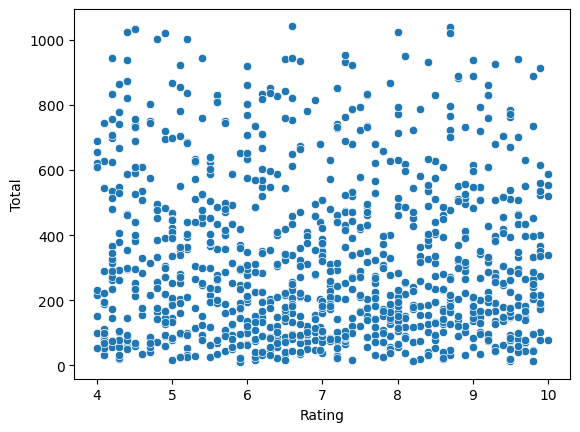

In [54]:
import seaborn as sns

sns.scatterplot( x =df["Rating"] , y=df["Total"])

<Axes: >

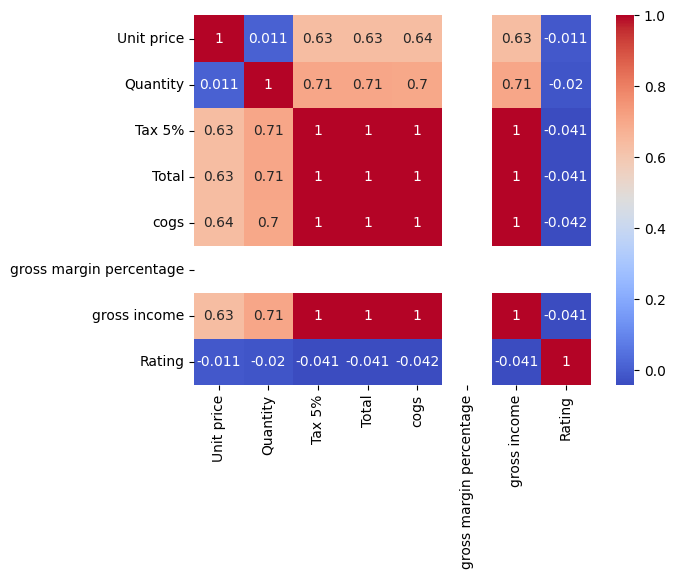

In [57]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

<Axes: xlabel='Quantity', ylabel='Total'>

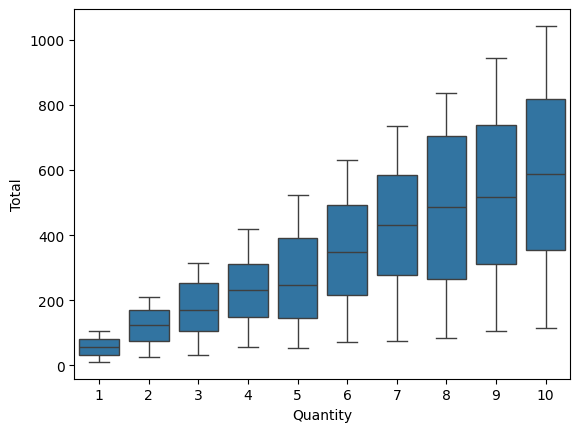

In [61]:
sns.boxplot(x=df["Quantity"],y=df["Total"])